In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans

In [3]:
dataset=pd.read_csv("../Datasets/customer_clustering_dataset.csv")
dataset.head()

,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100)
0,1,Female,40,30200,22
1,2,Female,20,27300,82
2,3,Male,36,86500,14
3,4,Female,38,94700,91
4,5,Female,26,80000,82


In [4]:
X=dataset.iloc[:,[3,4]].values

# **Elbow Method**

In [5]:
wcss=[]

for i in range(1,11):
    kmeans=KMeans(n_clusters=i,init="k-means++",random_state=0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

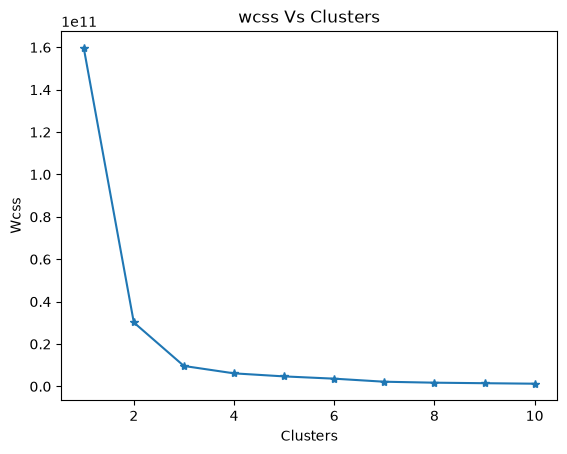

In [9]:
# Visualize the graph
plt.plot(range(1,11),wcss,marker="*")
plt.title("wcss Vs Clusters")
plt.xlabel("Clusters")
plt.ylabel("Wcss")
plt.show()

In [10]:
k_means=KMeans(n_clusters=5,init="k-means++",random_state=0)
y_means=k_means.fit_predict(X)

In [11]:
dataset["cluster"]=y_means

In [12]:
dataset.head()

,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),cluster
0,1,Female,40,30200,22,0
1,2,Female,20,27300,82,0
2,3,Male,36,86500,14,3
3,4,Female,38,94700,91,4
4,5,Female,26,80000,82,1


# **Visualize the Clusters**

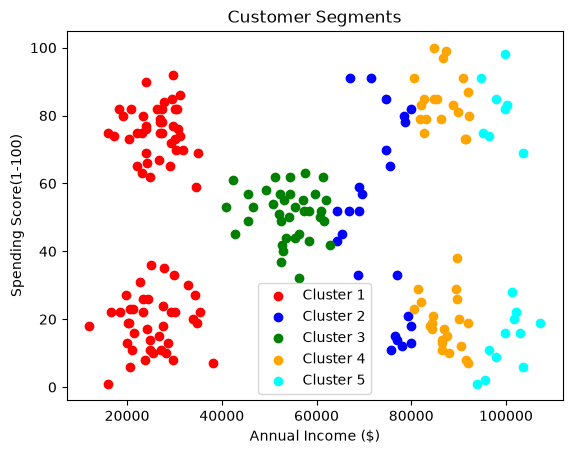

In [22]:
plt.scatter(X[y_means==0,0],X[y_means==0,1],label="Cluster 1",c="red")
plt.scatter(X[y_means==1,0],X[y_means==1,1],label="Cluster 2",c="blue")
plt.scatter(X[y_means==2,0],X[y_means==2,1],label="Cluster 3",c='green')
plt.scatter(X[y_means==3,0],X[y_means==3,1],label="Cluster 4",c='orange')
plt.scatter(X[y_means==4,0],X[y_means==4,1],label='Cluster 5',c='cyan')
plt.title("Customer Segments")
plt.xlabel("Annual Income ($)")
plt.ylabel("Spending Score(1-100)")
plt.legend()
plt.show()